In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os
import numpy as np

In [2]:
# export.xml is the full-scale data file, which includes all my sensitive data.
# Therefore, I will not upload it to GitHub. 
# This notebook will show you how everything works for pre-processing, and the results are given in data.xml and dates.json.

filepath = "./export.xml"
assert os.path.exists(filepath), "File does not exist: {}".format(filepath)

In [3]:
def deserialize_xml_file(filename):
    """
    Parses an XML file and returns the root element object.
    """
    try:
        # Load the XML data from the file
        tree = ET.parse(filename)
        # Get the root element of the XML tree
        root = tree.getroot()
        return root
    except ET.ParseError as e:
        print(f"Error parsing XML file: {e}")
        return None

In [4]:
root_element = deserialize_xml_file(filepath)

if root_element is not None:
    print(f"Root tag: {root_element.tag}")
    print(f"Number of child elements: {len(root_element)}")

SOURCE = "Yuxuan’s Apple Watch"
TARGET = "HKCategoryTypeIdentifierSleepAnalysis"

sleep_analysis = [r for r in root_element 
                  if r.tag == "Record" and \
                  r.attrib.get("type") == TARGET and \
                  r.attrib.get("sourceName") == SOURCE]

print(len(sleep_analysis))
print(sleep_analysis[0].attrib)

Root tag: HealthData
Number of child elements: 225382
2070
{'type': 'HKCategoryTypeIdentifierSleepAnalysis', 'sourceName': 'Yuxuan’s Apple\xa0Watch', 'sourceVersion': '26.2', 'creationDate': '2026-01-24 10:30:25 +0800', 'startDate': '2026-01-24 02:13:44 +0800', 'endDate': '2026-01-24 02:16:15 +0800', 'value': 'HKCategoryValueSleepAnalysisAsleepDeep'}


In [5]:
import datetime
def in_same_session(previous_date: datetime.datetime, current_date: datetime.datetime) -> bool:
    """
    Determines if two sleep sessions are part of the same sleep session based on their start and end times.
    Sleep sessions that are more than 1 hour apart are considered as different ones.
    """
    return (current_date.timestamp() - previous_date.timestamp()) < 3600

def str_to_datetime(date_str):
    """
    Converts a date string in the format "%Y-%m-%d %H:%M:%S %z" to a datetime object.
    """
    return datetime.datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S %z")

In [6]:
"""
Split sleep sessions by dates.
Sorry for having so many post-midnight sleep sessions. I have a very bad sleeping schedule.
"""
start_dates = [r.attrib.get("startDate") for r in sleep_analysis]
end_dates = [r.attrib.get("endDate") for r in sleep_analysis]
assert len(start_dates) == len(end_dates), "Start dates and end dates should have the same length."


"""
The variable "dates" serves as a hash table that maps each sleep session to 
a list of indexes in the "sleep_analysis" list, which stores the actual sleep data.
"""
dates = []

previous_start_date = str_to_datetime(start_dates[0])
previous_end_date = str_to_datetime(end_dates[0])
WEEKDAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# If the sleep session starts after midnight (and typically before 7 AM), we consider it as part of the previous day.
weekday = (previous_start_date.weekday() - 1) % 7 if previous_start_date.time() < datetime.time(7, 0, 0) else previous_start_date.weekday()
temp = [0]

for index, start_date in enumerate(start_dates[1:], start=1):
    start_date = str_to_datetime(start_date)
    end_date = str_to_datetime(end_dates[index])
    if in_same_session(previous_end_date, start_date):
        temp.append(index)
    else:
        dates.append([WEEKDAYS[weekday], temp])
        weekday = (start_date.weekday() - 1) % 7 if start_date.time() < datetime.time(7, 0, 0) else start_date.weekday()
        temp = [index]
    previous_start_date = start_date
    previous_end_date = end_date

dates.append([WEEKDAYS[weekday], temp])

print(f"Total sleep sessions: {len(dates)}")
print(f"First sleep session: {dates[0]}")

Total sleep sessions: 66
First sleep session: ['Fri', [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]]


In [7]:
SYMBOLS = {
    "HKCategoryValueSleepAnalysisAwake": 0,
    "HKCategoryValueSleepAnalysisAsleepREM": 1,
    "HKCategoryValueSleepAnalysisAsleepCore": 2,
    "HKCategoryValueSleepAnalysisAsleepDeep": 3,
    "HKCategoryValueSleepAnalysisAsleepUnspecified": 4,
}

SLEEP_COLORS = {
    0: "tab:orange",
    1: "tab:blue",
    2: "tab:green",
    3: "tab:purple",
    4: "tab:gray",
}

SLEEP_LABELS = {
    0: "AWAKE",
    1: "REM",
    2: "CORE",
    3: "DEEP",
    4: "UNSPECIFIED",
}

In [8]:
def parse_sleep_datetime(date_string):
    return datetime.datetime.strptime(date_string, "%Y-%m-%d %H:%M:%S %z")


def draw_sleep_session(weekday, session):
    """
    Draws a sleep session using the actual startDate/endDate values for placement.
    """
    records = [sleep_analysis[index] for index in session]
    starts = [parse_sleep_datetime(record.attrib["startDate"]) for record in records]
    ends = [parse_sleep_datetime(record.attrib["endDate"]) for record in records]
    categories = [SYMBOLS[record.attrib.get("value")] for record in records]

    session_start = min(starts)
    lefts = [(start - session_start).total_seconds() / 60.0 for start in starts]
    widths = [(end - start).total_seconds() / 60.0 for start, end in zip(starts, ends)]
    min_display_width = 5.0
    display_widths = [max(width, min_display_width) for width in widths]

    fig, ax = plt.subplots(figsize=(12, 2))
    for left, width, category in zip(lefts, display_widths, categories):
        ax.broken_barh(
            [(left, width)],
            (0, 1),
            facecolors=SLEEP_COLORS.get(category, "gray"),
            edgecolor="black",
            linewidth=0.5,
        )

    ax.set_ylim(0, 1)
    ax.set_yticks([0.5])
    ax.set_yticklabels(["Sleep state"])

    total_minutes = max(left + width for left, width in zip(lefts, widths))
    tick_interval = 15
    xticks = np.arange(0, total_minutes + tick_interval, tick_interval)
    ax.set_xticks(xticks)
    ax.set_xticklabels([
        (session_start + datetime.timedelta(minutes=int(minutes))).strftime("%H:%M")
        for minutes in xticks
    ], rotation=45)

    ax.set_xlabel("Time")
    ax.set_title(
        f"Sleep Session Visualization - {weekday} (start {session_start.strftime('%Y-%m-%d %H:%M')})"
    )

    legend_patches = [
        plt.Line2D([0], [0], color=SLEEP_COLORS[state], lw=6)
        for state in sorted(SLEEP_COLORS)
    ]# Swap the positions of the labels and the patches
    ax.legend(
        legend_patches, 
        [SLEEP_LABELS[state] for state in sorted(SLEEP_COLORS)], 
        loc="upper right", 
        ncol=len(SLEEP_COLORS)
    )
    
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

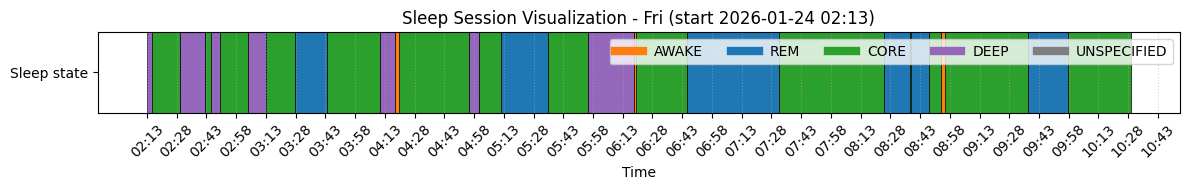

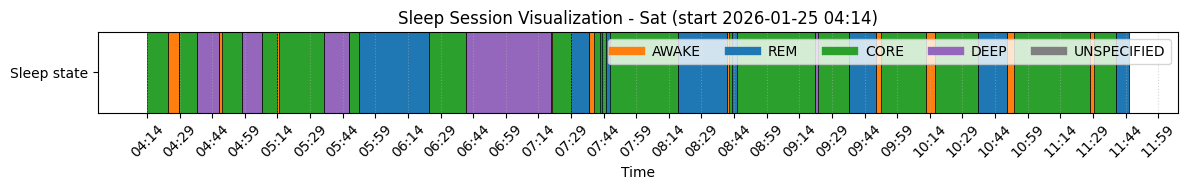

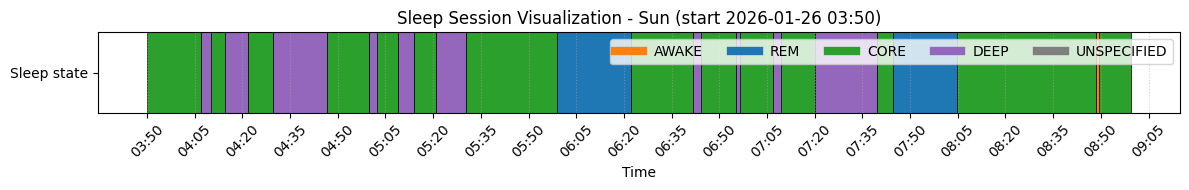

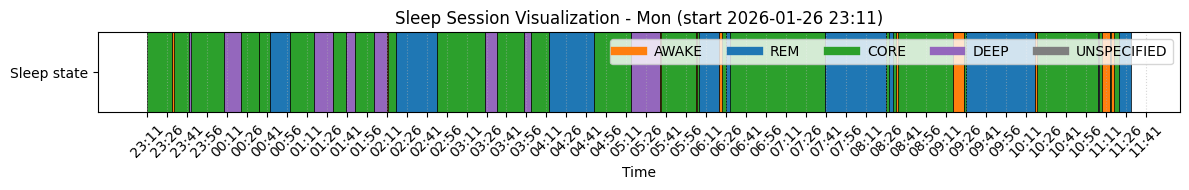

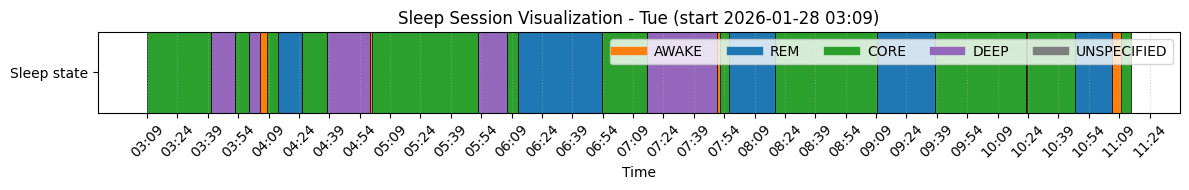

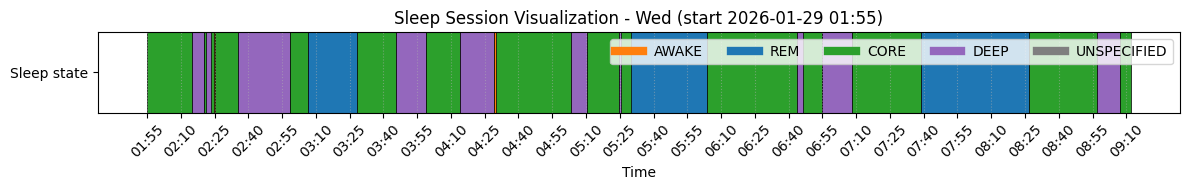

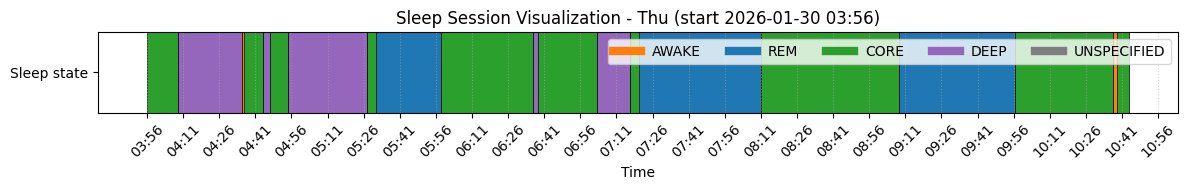

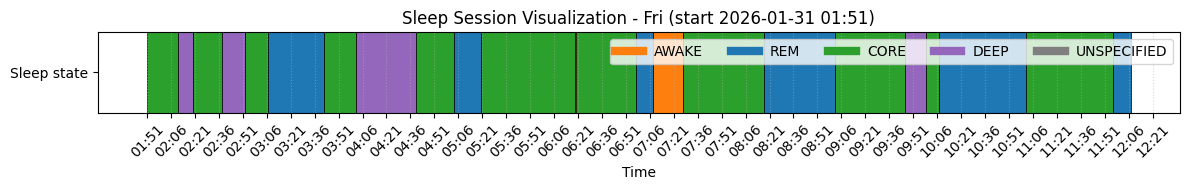

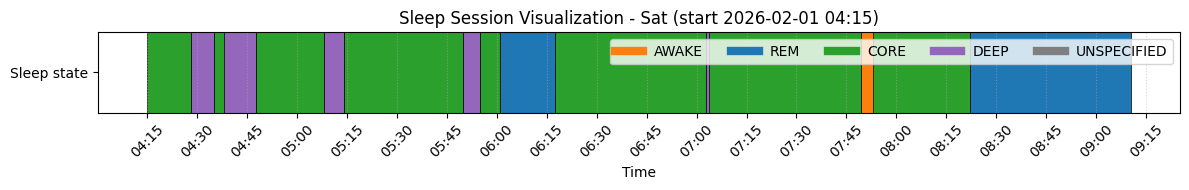

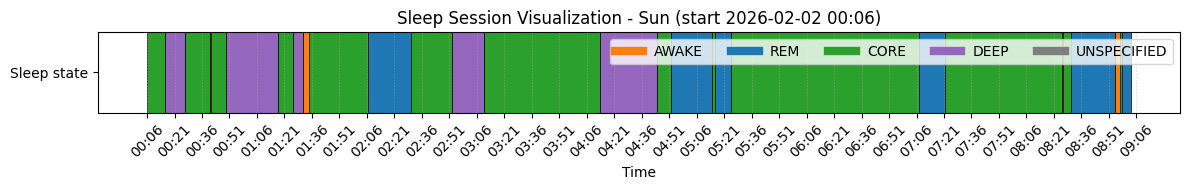

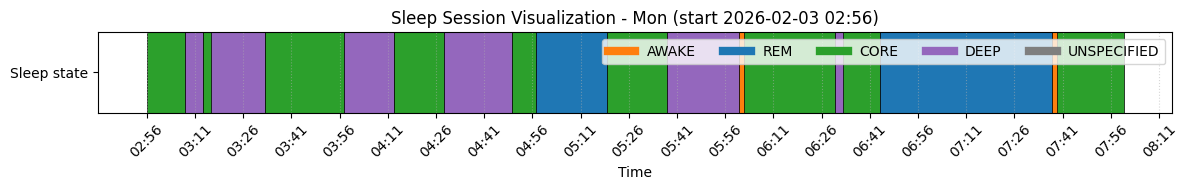

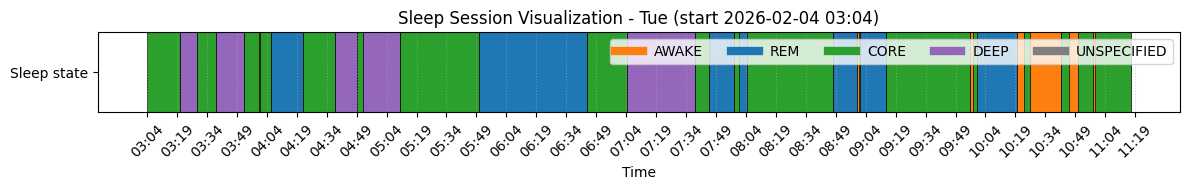

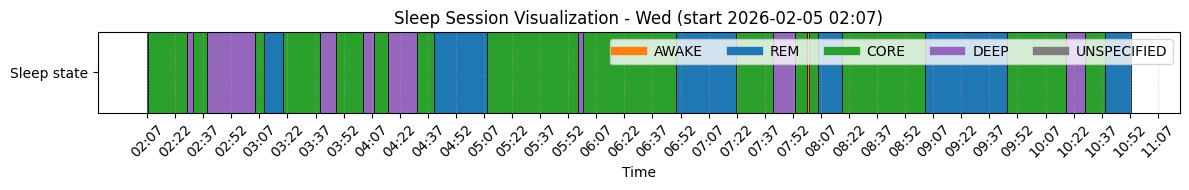

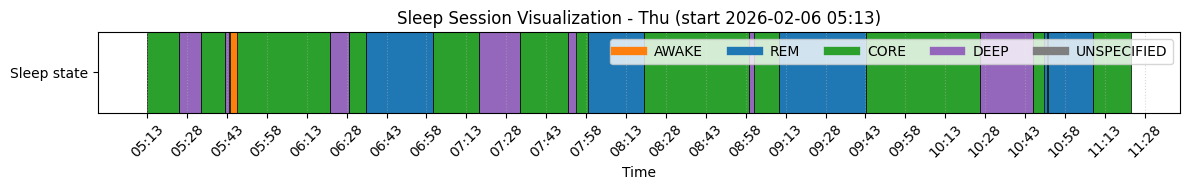

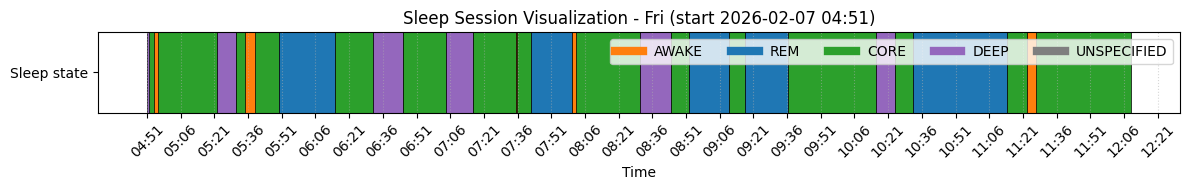

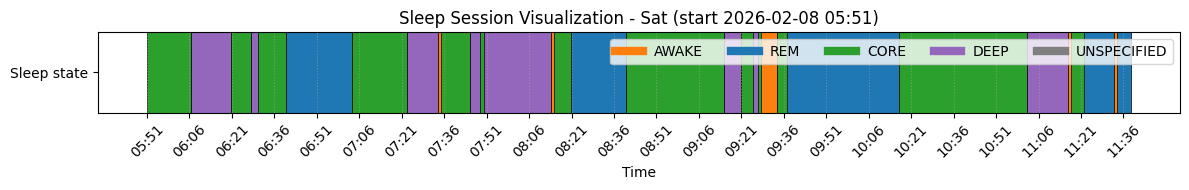

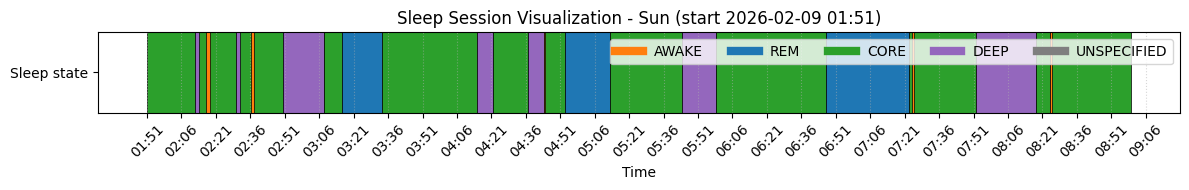

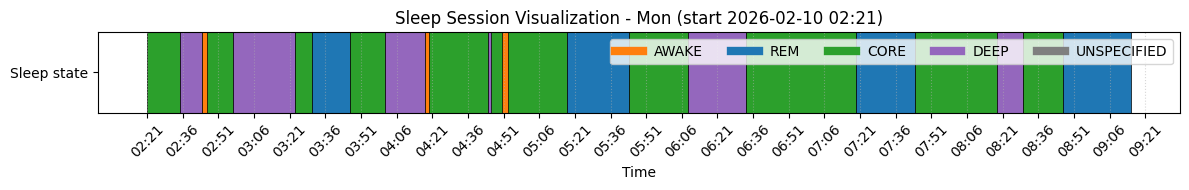

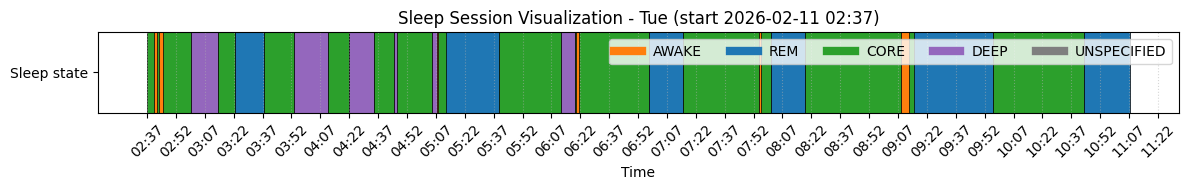

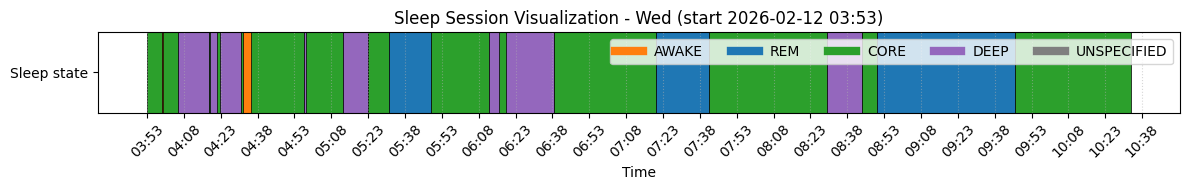

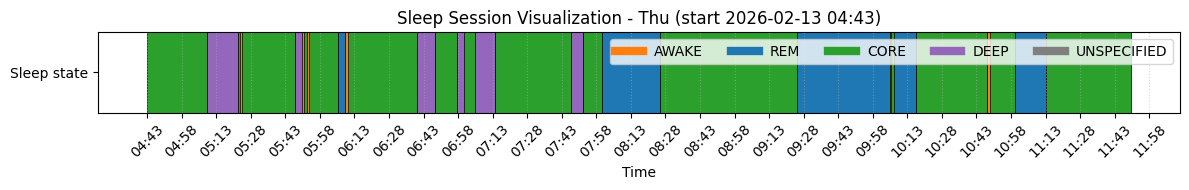

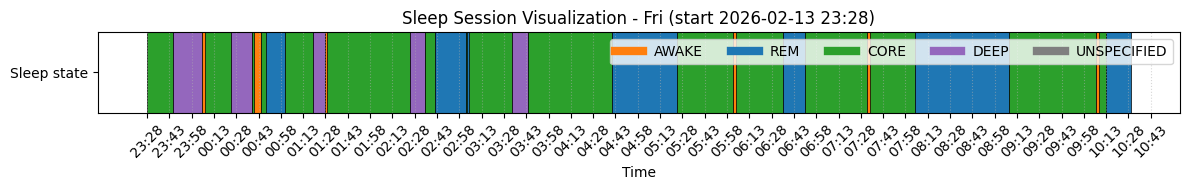

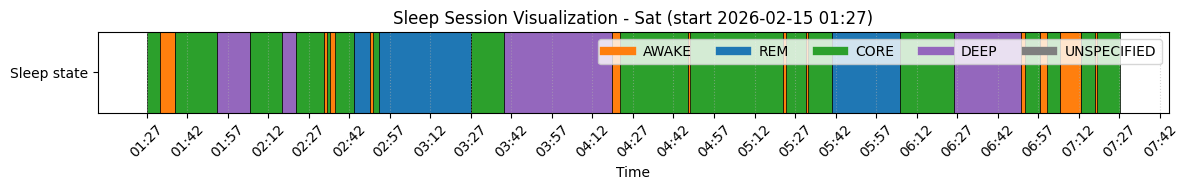

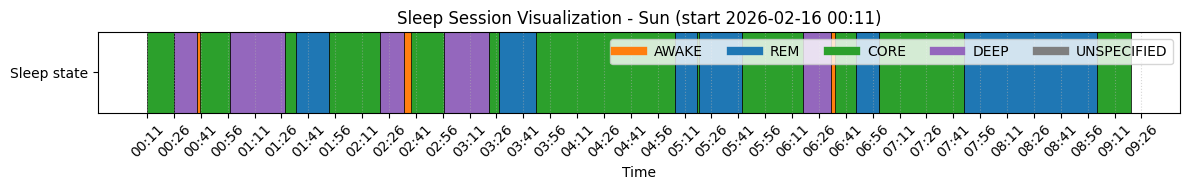

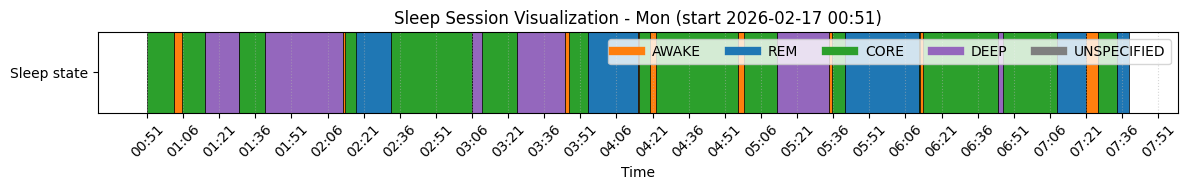

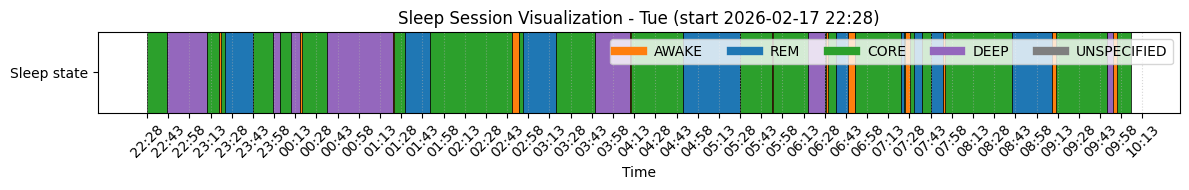

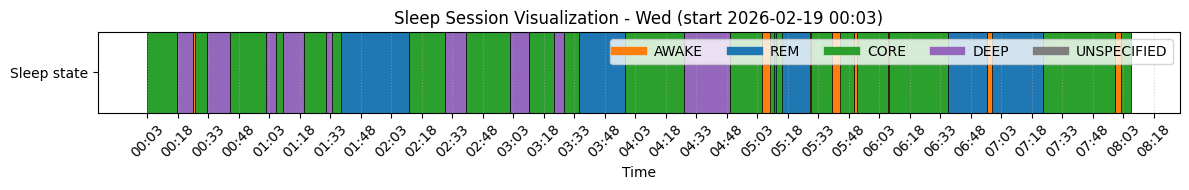

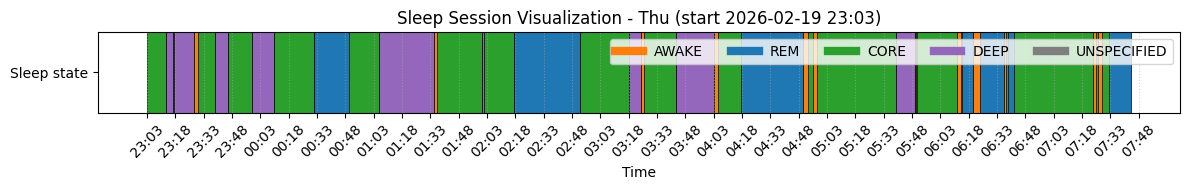

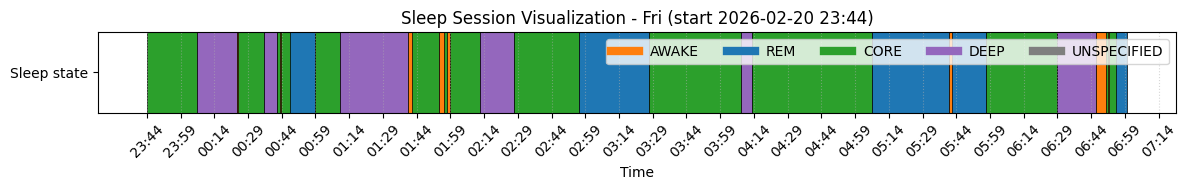

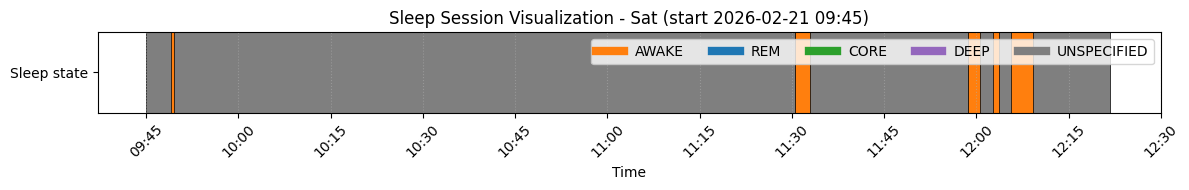

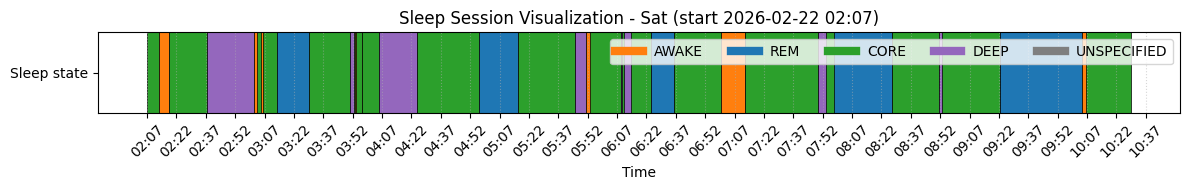

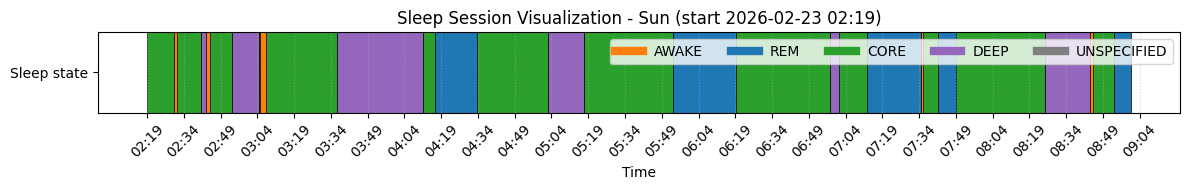

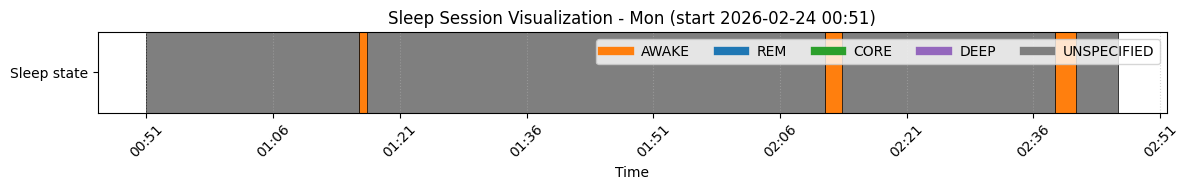

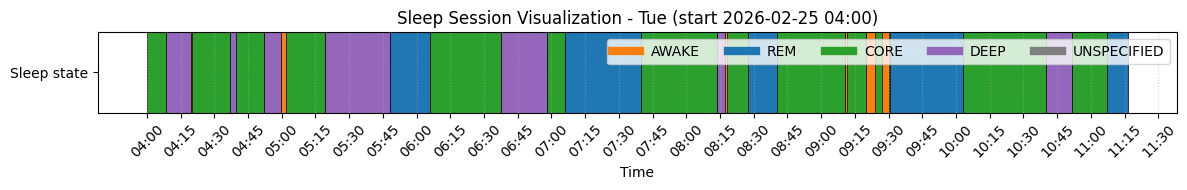

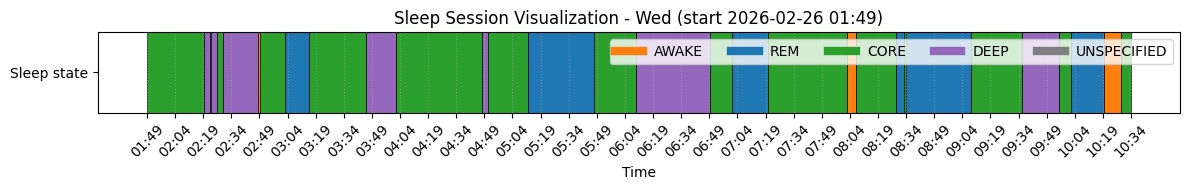

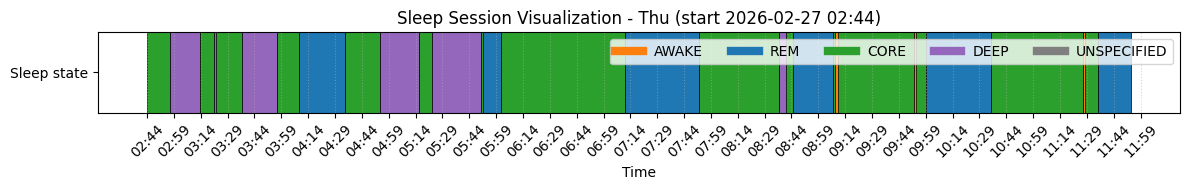

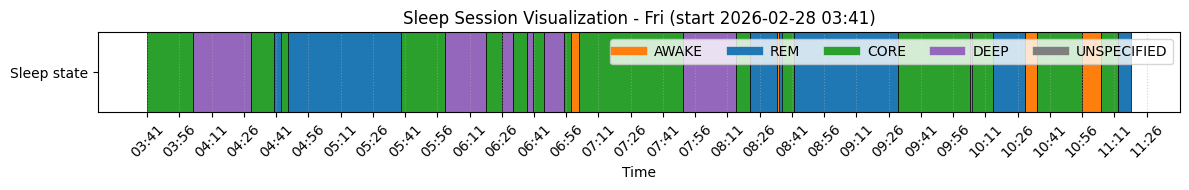

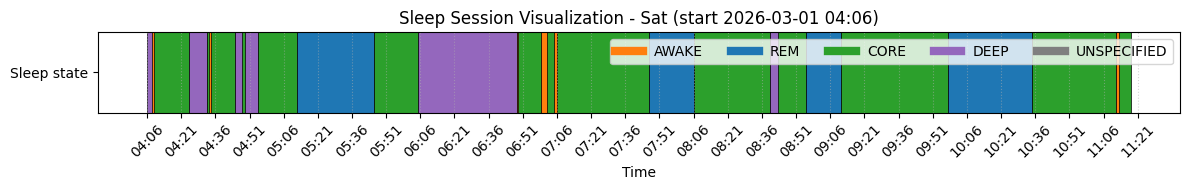

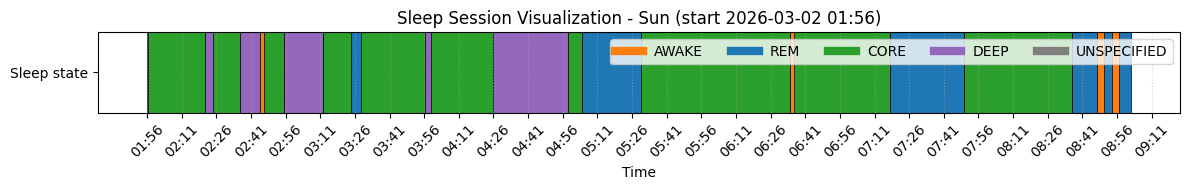

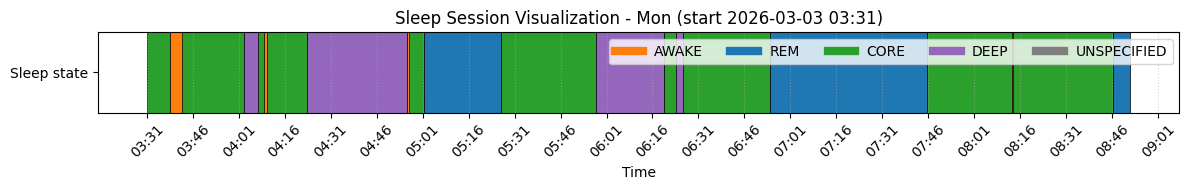

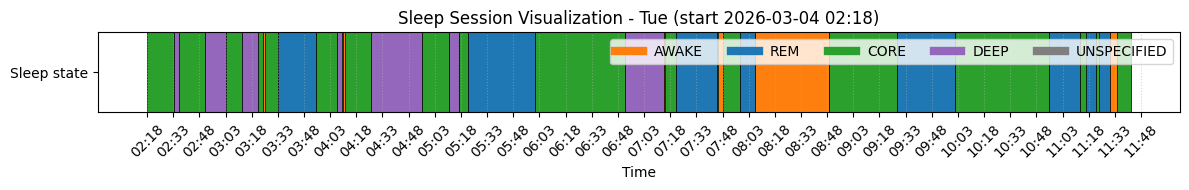

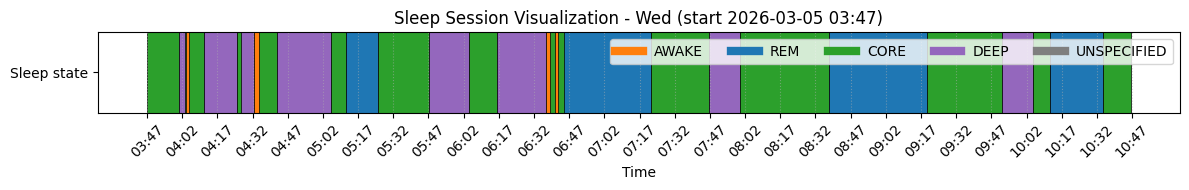

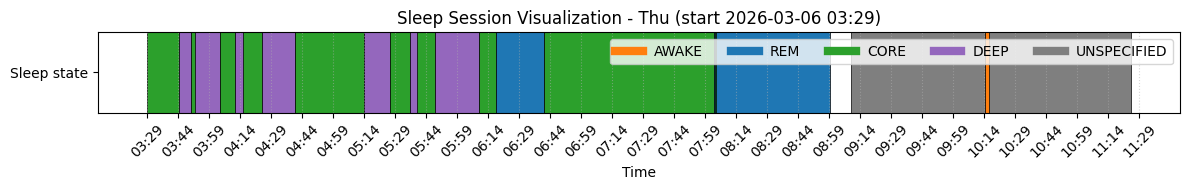

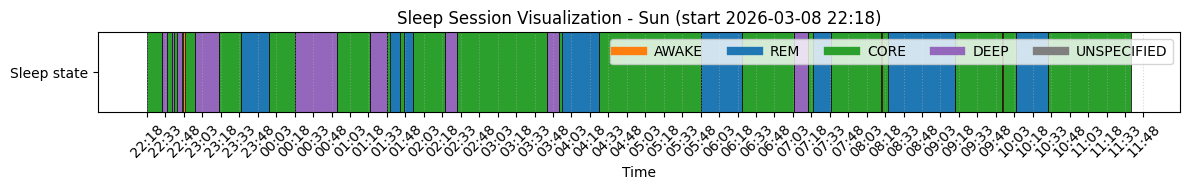

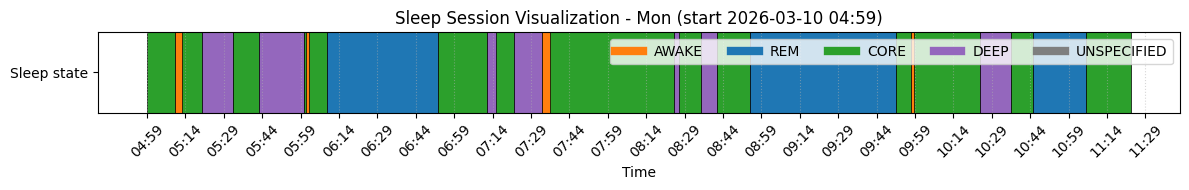

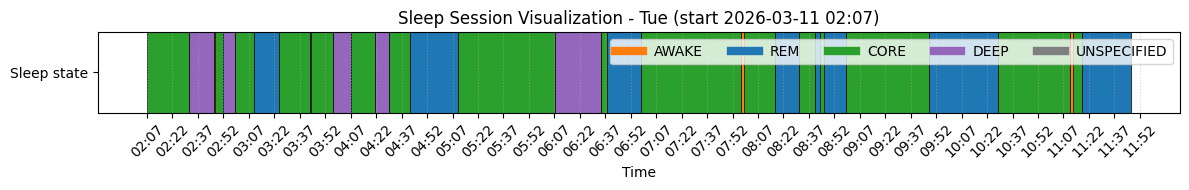

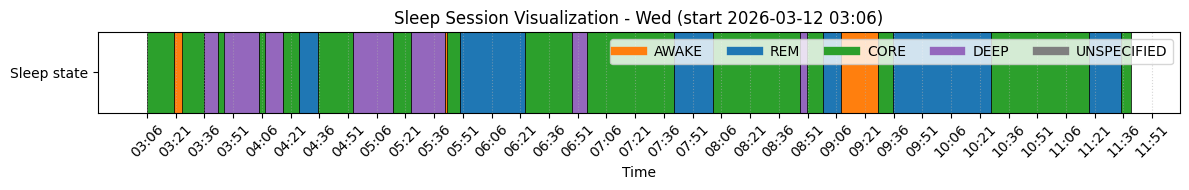

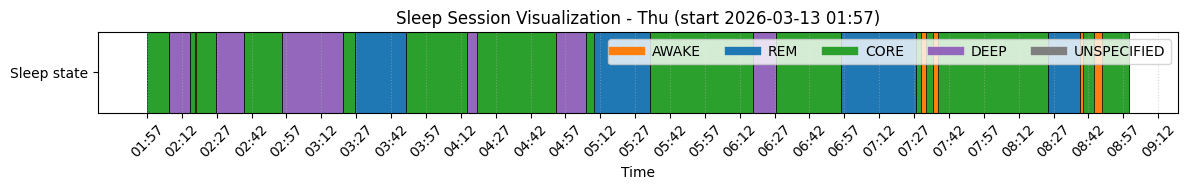

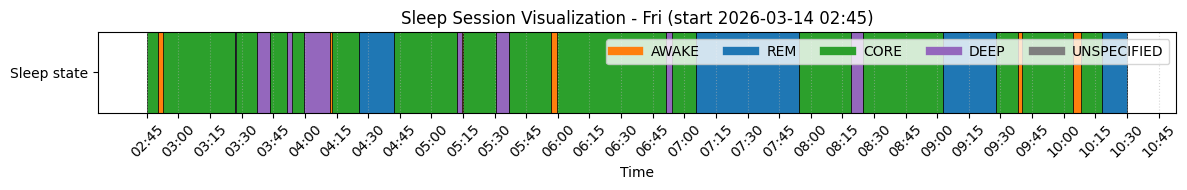

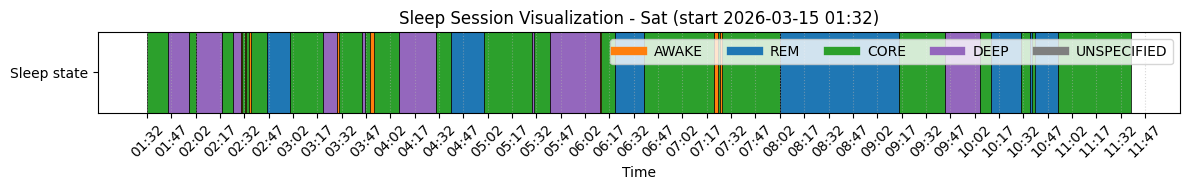

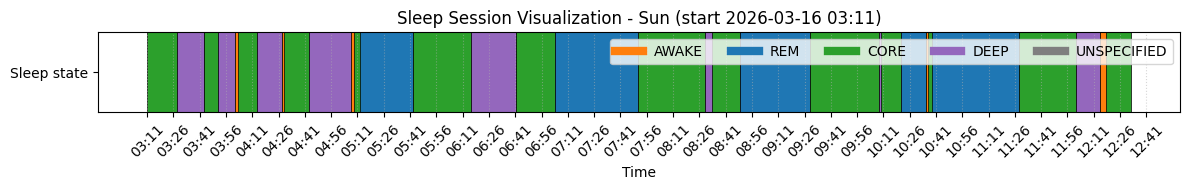

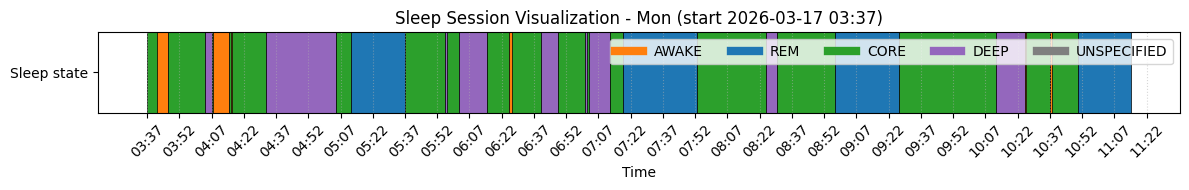

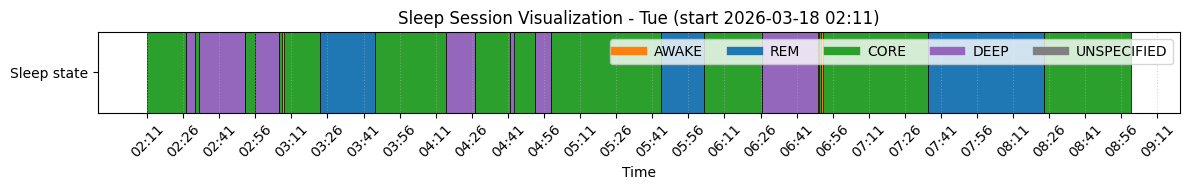

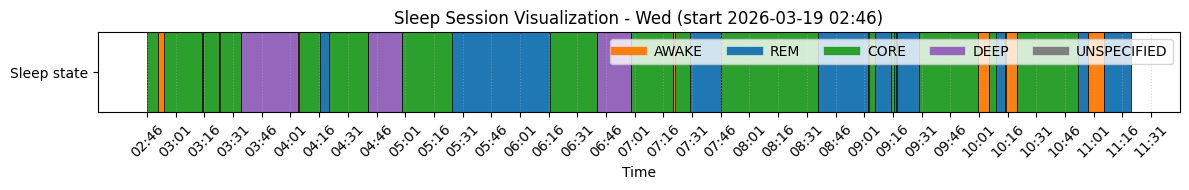

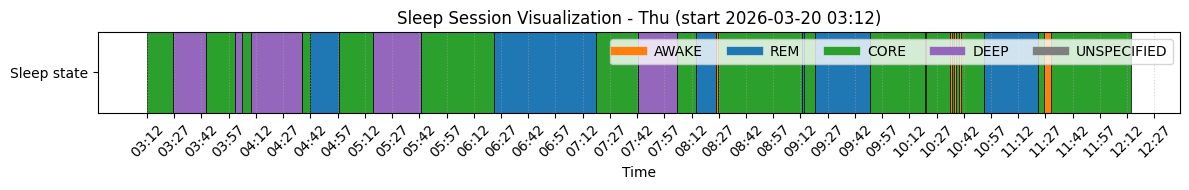

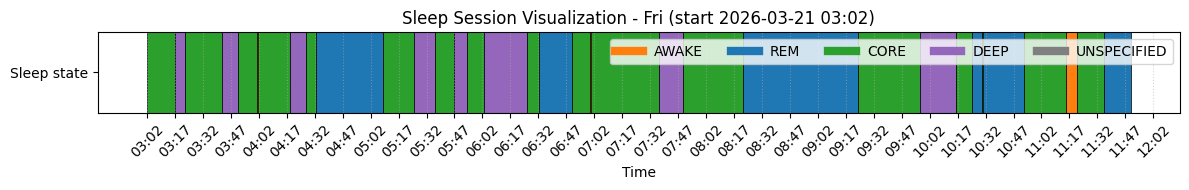

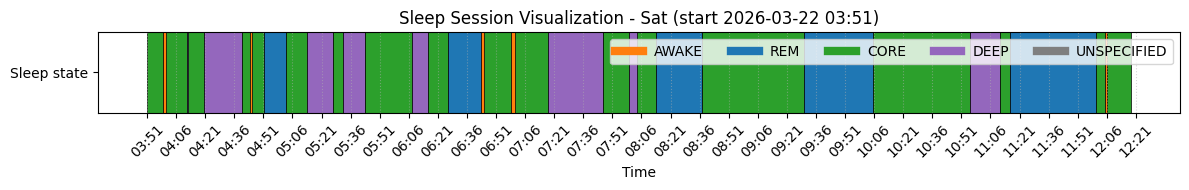

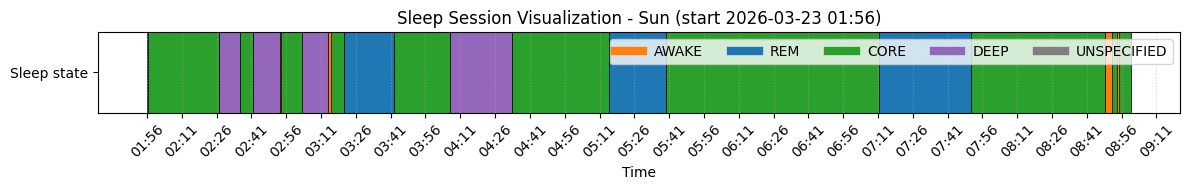

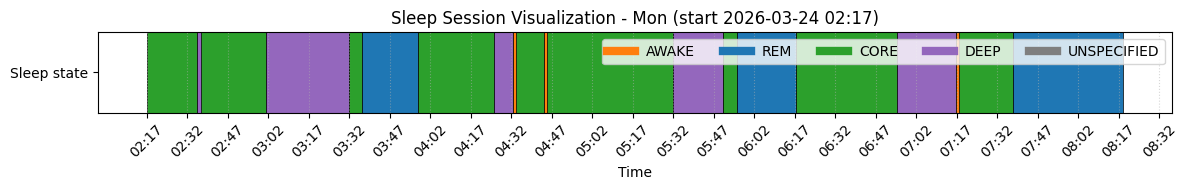

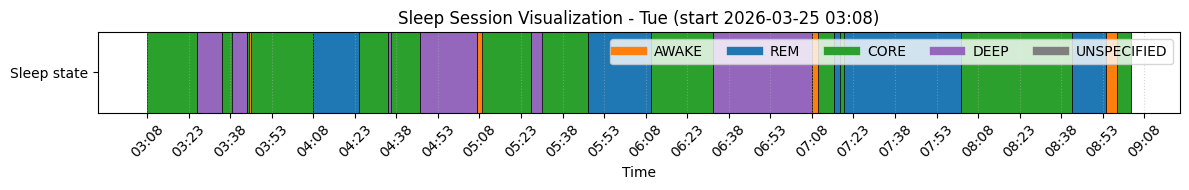

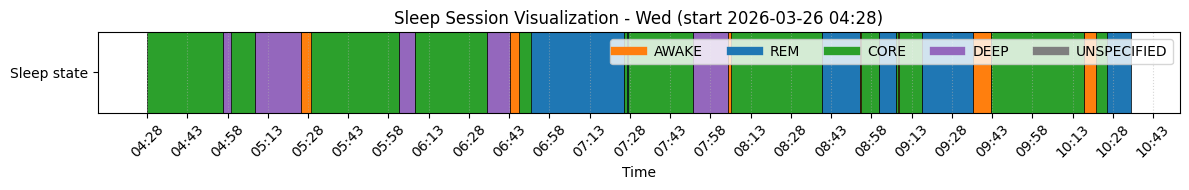

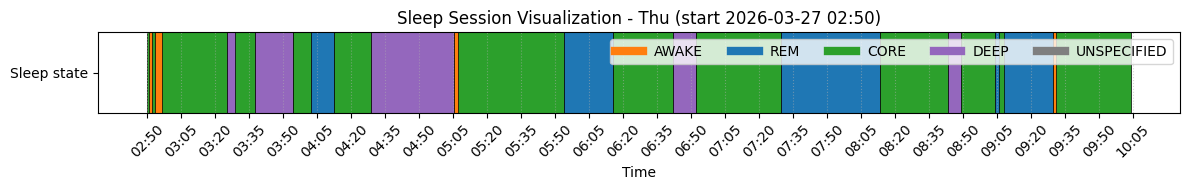

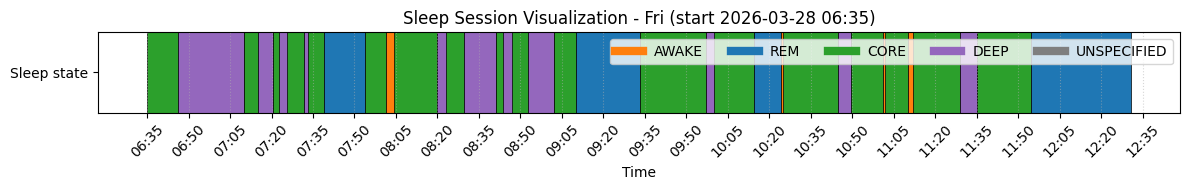

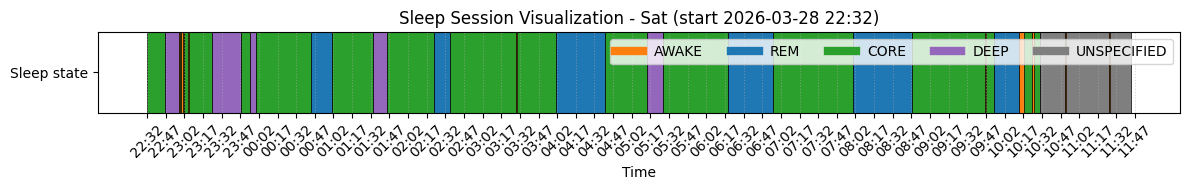

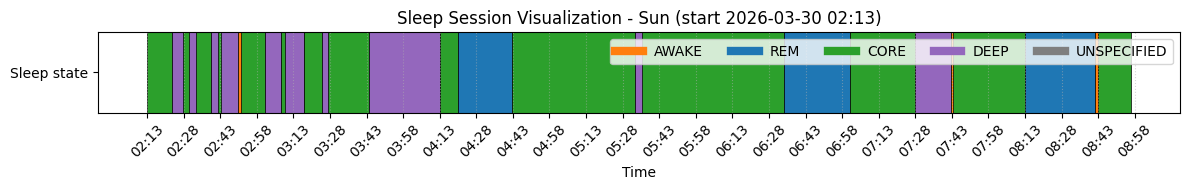

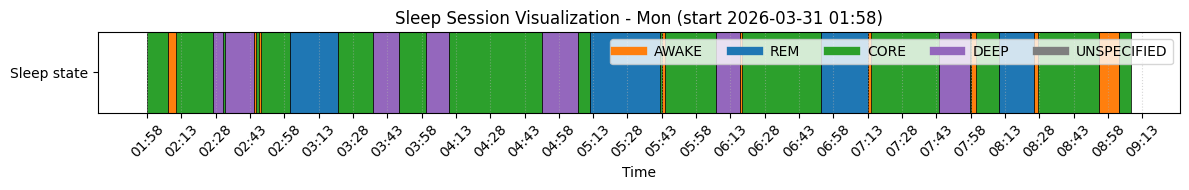

In [9]:
for i in range(len(dates)):
    draw_sleep_session(dates[i][0], dates[i][1])

In [10]:
def save_raw_data():
    root = ET.Element("SleepData")
    for data in sleep_analysis:
        record = ET.SubElement(root, "Record", attrib=data.attrib)
    tree = ET.ElementTree(root)
    ET.indent(tree, space="\t", level=0)
    with open("./data.xml", "wb") as f:
        tree.write(f, encoding="utf-8", xml_declaration=True)

def save_date_table():
    import json
    date_string = json.dumps(dates, indent=4)
    with open("./dates.json", "w") as f:
        f.write(date_string)

save_raw_data()
save_date_table()